In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from kneed import KneeLocator
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

### Loading scRNA-seq data

In [2]:
# Selecting the brain region
select_region = "Isocortex-1"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 227670 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
# Count the number of cells in each class
class_counts = adata.obs["class"].value_counts()
print(class_counts)

class
01 IT-ET Glut        121827
02 NP-CT-L6b Glut     57507
07 CTX-MGE GABA       13401
06 CTX-CGE GABA       12688
31 OPC-Oligo           6465
30 Astro-Epen          6372
33 Vascular            4813
34 Immune              3607
08 CNU-MGE GABA         432
05 OB-IMN GABA          213
03 OB-CR Glut            89
04 DG-IMN Glut           52
09 CNU-LGE GABA          43
32 OEC                   36
11 CNU-HYa GABA          31
12 HY GABA               30
14 HY Glut               25
25 Pineal Glut           19
13 CNU-HYa Glut           8
16 HY MM Glut             7
24 MY Glut                2
10 LSX GABA               1
15 HY Gnrh1 Glut          1
27 MY GABA                1
Name: count, dtype: int64


In [5]:
# Identify classes with few cells
n_cells_threshold = 100

# Filter out the cells belonging to the identified classes
classes_to_remove = class_counts[class_counts < n_cells_threshold].index.tolist()
adata = adata[~adata.obs["class"].isin(classes_to_remove)].copy()

print(f"Classes with less than {n_cells_threshold} cells ({classes_to_remove}) have been removed.")
adata

Classes with less than 100 cells (['03 OB-CR Glut', '04 DG-IMN Glut', '09 CNU-LGE GABA', '32 OEC', '11 CNU-HYa GABA', '12 HY GABA', '14 HY Glut', '25 Pineal Glut', '13 CNU-HYa Glut', '16 HY MM Glut', '24 MY Glut', '10 LSX GABA', '15 HY Gnrh1 Glut', '27 MY GABA']) have been removed.


AnnData object with n_obs × n_vars = 227325 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [6]:
gene_names_df = adata.var.copy()
adata.var.set_index("gene_symbol", inplace=True)

### Quality control

In [13]:
mt_genes = adata.var_names.str.lower().str.startswith("mt-")
print(f"Number of mitochondrial genes: {mt_genes.sum()}")
print("Mitochondrial genes:", adata.var_names[mt_genes].tolist())


Number of mitochondrial genes: 13
Mitochondrial genes: ['mt-Nd1', 'mt-Nd2', 'mt-Co1', 'mt-Co2', 'mt-Atp8', 'mt-Atp6', 'mt-Co3', 'mt-Nd3', 'mt-Nd4l', 'mt-Nd4', 'mt-Nd5', 'mt-Nd6', 'mt-Cytb']


In [14]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("mt-")

In [15]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=True, log1p=True
)

In [16]:
adata.var_names = adata.var_names.astype(str)  # ensure it's a string index
adata.var_names_make_unique()  # now it will work

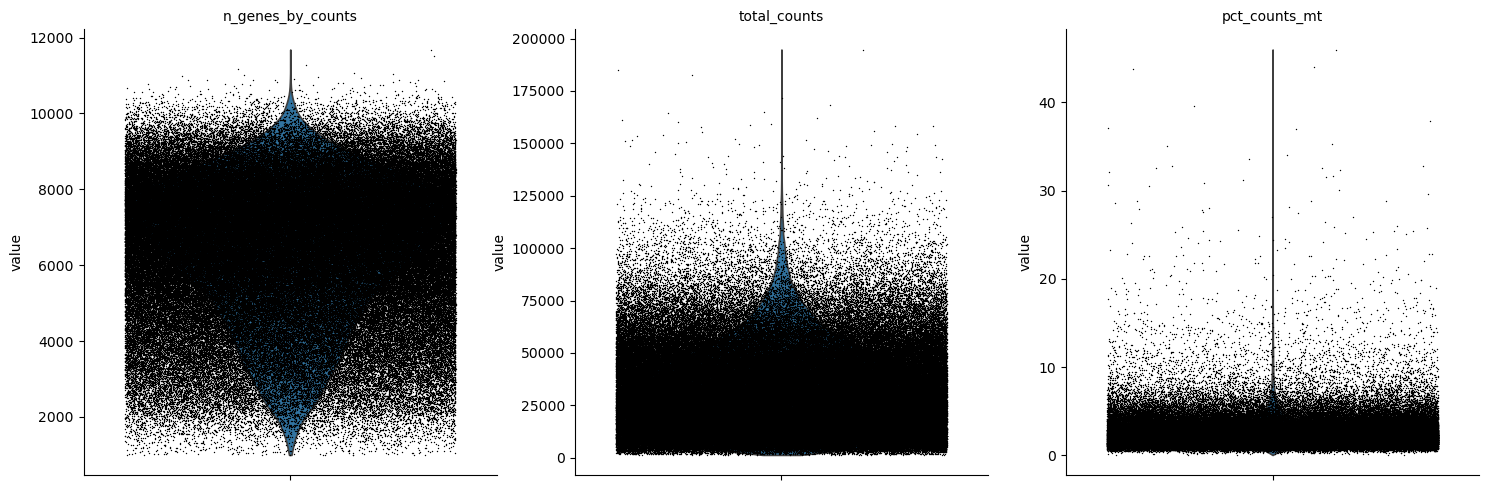

In [17]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

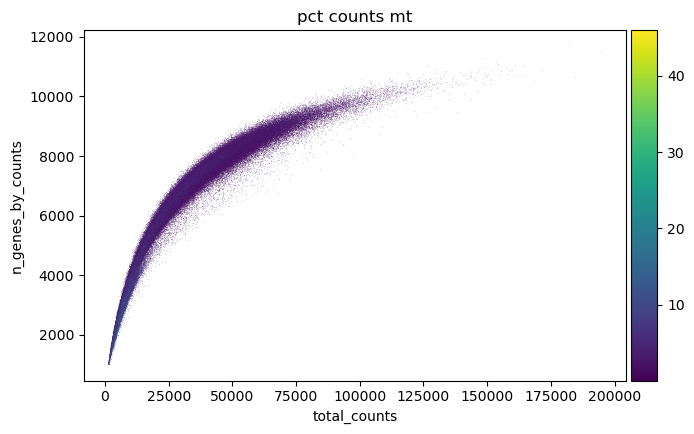

In [18]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

### Normalization and Log transformation

In [19]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [20]:
# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
adata.raw = adata # Save raw log-normalized data

### Highly Variable Gene selection

In [8]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)  # Select highly variable genes, subset=True

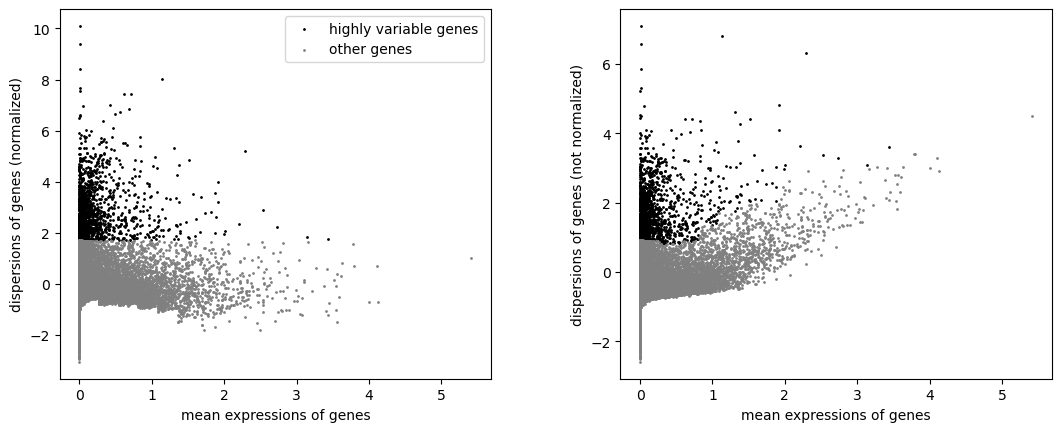

In [9]:
sc.pl.highly_variable_genes(adata)

In [10]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)

### Dimensionality Reduction

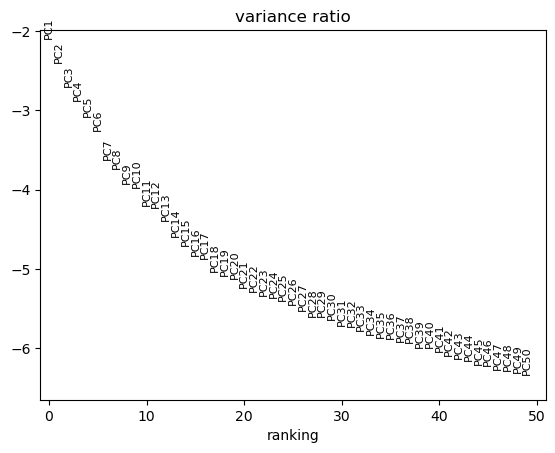

In [11]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [12]:
# Assuming `adata` has run PCA
variance_ratio = adata.uns['pca']['variance_ratio']
x = range(1, len(variance_ratio)+1)

knee = KneeLocator(x, variance_ratio, curve='convex', direction='decreasing')
print(f"Elbow at PC: {knee.knee}")

Elbow at PC: 11


In [13]:
sc.tl.pca(adata, n_comps=knee.knee)

### Neighborhood graph

In [14]:
sc.pp.neighbors(adata)

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
sc.tl.umap(adata)

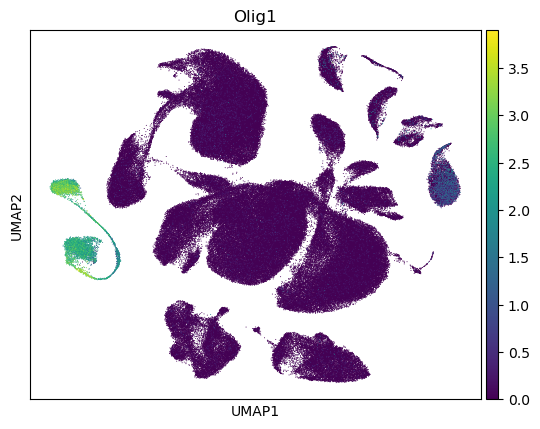

In [16]:
sc.pl.umap(adata, color="Olig1", size=2)

### Clustering

In [17]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

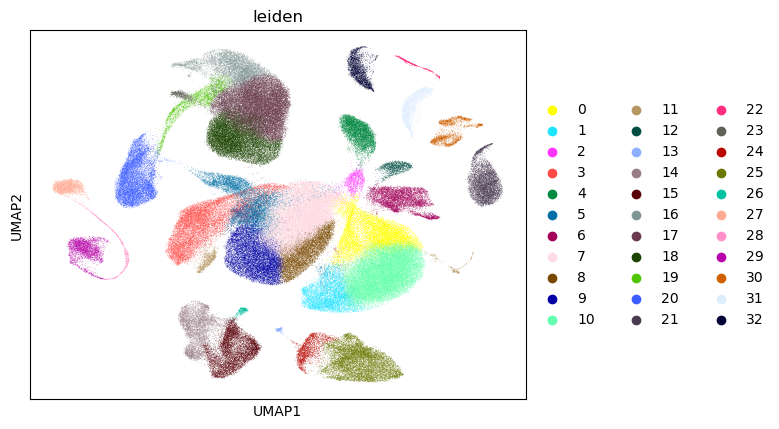

In [18]:
sc.pl.umap(adata, color=["leiden"])

In [19]:
for res in [0.001,0.002,0.006,0.01]:
    sc.tl.leiden(adata, flavor="igraph", n_iterations=2, key_added=f'leiden_{res}', resolution=res)
    ari = adjusted_rand_score(adata.obs['class'], adata.obs[f'leiden_{res}'])
    print(f"Resolution {res} → ARI: {ari:.3f}")

Resolution 0.001 → ARI: 0.980
Resolution 0.002 → ARI: 0.980
Resolution 0.006 → ARI: 0.937
Resolution 0.01 → ARI: 0.937


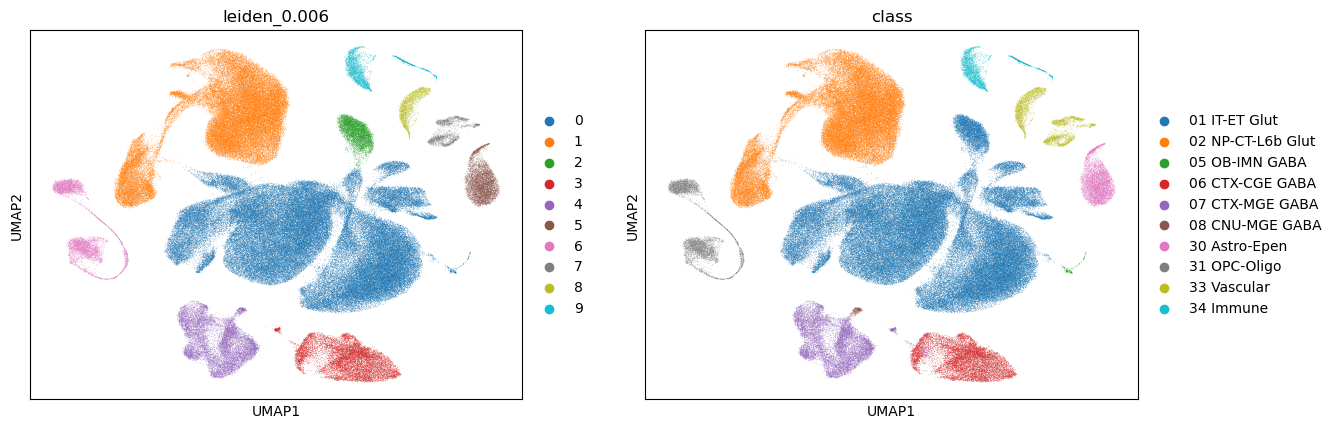

In [20]:
sc.pl.umap(adata, color=["leiden_0.006","class"])

In [21]:
for res in [0.04,0.08,0.1,0.15,0.2,0.3]:
    sc.tl.leiden(adata, flavor="igraph", n_iterations=2, key_added=f'leiden_{res}', resolution=res)
    ari = adjusted_rand_score(adata.obs['subclass'], adata.obs[f'leiden_{res}'])
    print(f"Resolution {res} → ARI: {ari:.3f}")

Resolution 0.04 → ARI: 0.691
Resolution 0.08 → ARI: 0.814
Resolution 0.1 → ARI: 0.822
Resolution 0.15 → ARI: 0.842
Resolution 0.2 → ARI: 0.850
Resolution 0.3 → ARI: 0.833


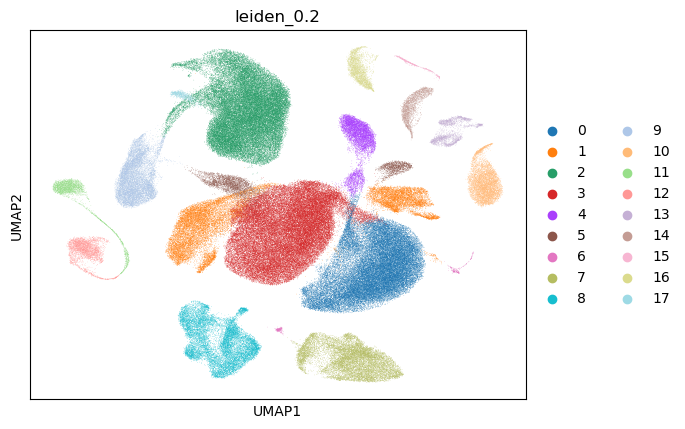

In [23]:
sc.pl.umap(adata, color=["leiden_0.2"])

In [25]:
sc.write(base_path / f"AnnData/WMB-10Xv3-{select_region}-raw-wmeta-DEGpp.h5ad",
         adata = adata)